# Predicción de churn

### 1. Realizar un análisis exploratorio de los datos para comprender las características y la distribución de los datos


In [34]:
# importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import graphviz
import warnings
warnings.filterwarnings('ignore')

# Librerías para clustering
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import export_graphviz, DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset
df = pd.read_excel("Telco-Customer-Churn.xlsx")

### Funcion para el análisis del dataset 

In [35]:
# Análisis general del dataset
def analisis_general(df):   # función para realizar un análisis general del dataset
    
    # Imprimimos los resultados del análisis general
    print("ANÁLISIS GENERAL DEL DATASET\n")  
    print("\n🔹 Primeros registros:")
    display(df.head())

    # Info
    print("\n🔹 Información del dataset:")
    df.info()

    # Tipos de datos
    print("\n🔹 Tipos de datos:")
    display(df.dtypes)

    # Nulos
    print("\n🔹 Valores nulos:")
    display(df.isnull().sum())

    # Duplicados
    print("\n🔹 Duplicados:")
    print(df.duplicated().sum())

    # Estadísticas
    print("\n🔹 Estadísticas descriptivas:")
    display(df.describe())

In [36]:
# Ejecutamos el análisis general
analisis_general(df)

ANÁLISIS GENERAL DEL DATASET


🔹 Primeros registros:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



🔹 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


🔹 Valores nulos:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


🔹 Duplicados:
0

🔹 Estadísticas descriptivas:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Se identificaron 11 valores nulos en la variable TotalCharges, los cuales seran eliminados debido a su baja proporción en el dataset, evitando así posibles distorsiones en el análisis.

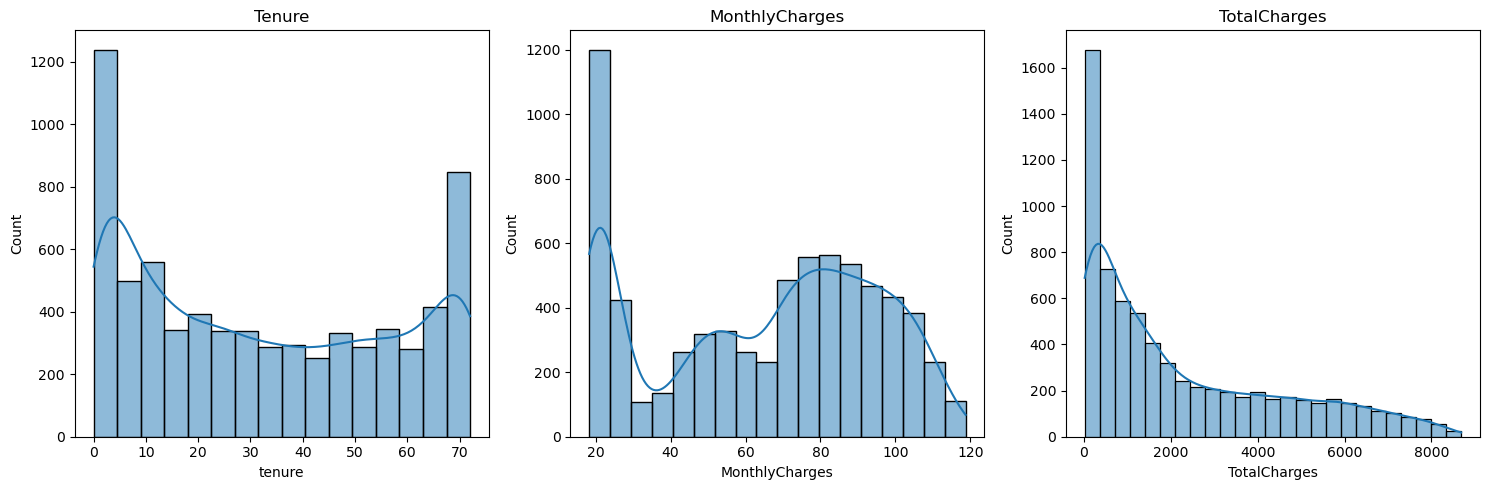

In [37]:
# Análisis univariado
fig, axes = plt.subplots(1, 3, figsize=(15,5))              # creamos una figura con 3 subplots para los histogramas

sns.histplot(df["tenure"], kde=True, ax=axes[0])            # creamos un histograma para la variable "tenure" con una curva de densidad (kde) y lo asignamos al primer subplot
axes[0].set_title("Tenure")                                 # establecemos el título del primer subplot

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1])    # creamos un histograma para la variable "MonthlyCharges" con una curva de densidad (kde) y lo asignamos al segundo subplot
axes[1].set_title("MonthlyCharges")                         # establecemos el título del segundo subplot

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2])      # creamos un histograma para la variable "TotalCharges" con una curva de densidad (kde) y lo asignamos al tercer subplot
axes[2].set_title("TotalCharges")                           # establecemos el título del tercer subplot

plt.tight_layout()                                          # ajustamos el diseño de la figura para que no se solapen los subplots
plt.show()                                                  # mostramos la figura con los histogramas

Las variables presentan distribuciones no uniformes. Tenure muestra concentración en valores bajos y altos, indicando clientes nuevos y antiguos. MonthlyCharges presenta una distribución más equilibrada, mientras que TotalCharges está sesgada a la derecha, evidenciando la presencia de valores altos acumulados en clientes de mayor antigüedad.

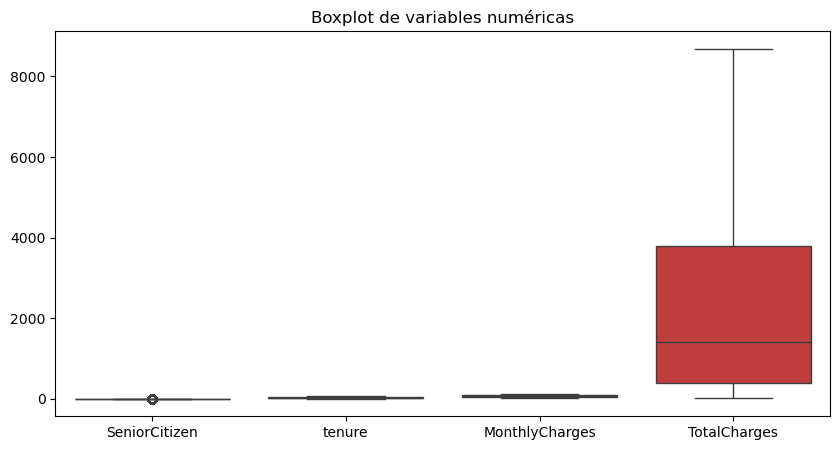

In [38]:
# Análisis bivariado
plt.figure(figsize=(10,5))                                      # creamos una figura con un tamaño de 10x5 pulgadas para el gráfico
sns.boxplot(data=df.select_dtypes(include=['int64','float64'])) # creamos un boxplot para las variables numéricas del dataset utilizando seaborn y lo asignamos a la figura
plt.title("Boxplot de variables numéricas")                     # establecemos el título del gráfico
plt.show()                                                      # mostramos el gráfico

Se observan valores extremos principalmente en TotalCharges, lo que indica alta dispersión en el gasto acumulado de los clientes. Las demás variables presentan menor variabilidad, siendo SeniorCitizen una variable binaria sin relevancia para análisis de outliers. Estos valores extremos corresponden al comportamiento real del negocio y no requieren eliminación inmediata.

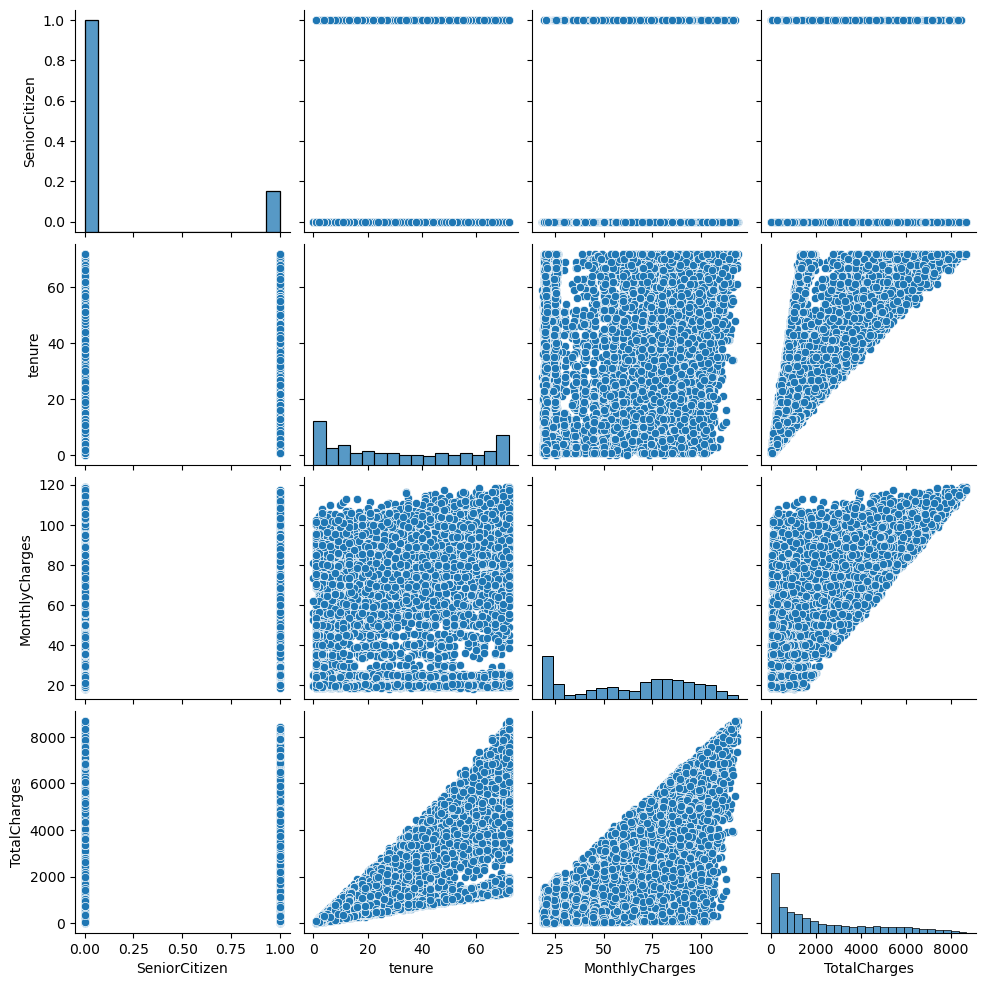

In [39]:
# Gráficos de dispersión
sns.pairplot(df.select_dtypes(include=['int64','float64'])) # creamos un pairplot para las variables numéricas del dataset utilizando seaborn, lo que nos permite visualizar las relaciones entre cada par de variables numéricas
plt.show()                                                  # mostramos el gráfico de dispersión

Se observa una fuerte relación positiva entre tenure y TotalCharges, lo que indica que los clientes con mayor antigüedad tienden a acumular mayor gasto. Asimismo, MonthlyCharges también muestra una relación directa con TotalCharges. La variable SeniorCitizen no presenta una relación clara con las variables numéricas, por lo que su impacto en el comportamiento de gasto es limitado.

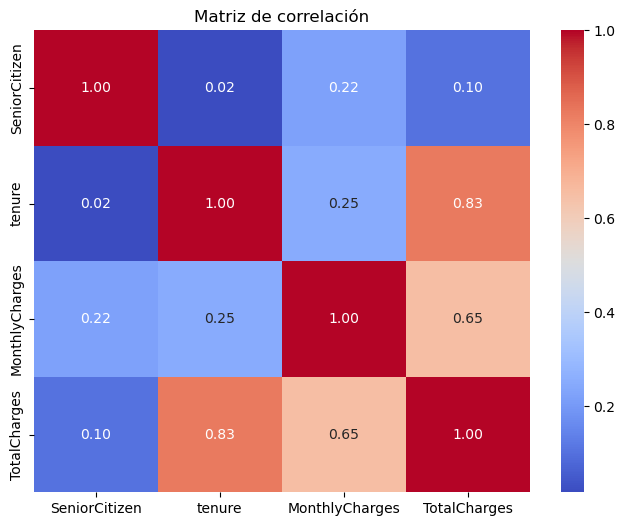

In [40]:
# Matriz de correlación
corr = df.select_dtypes(include=['int64','float64']).corr() # Calcula la matriz de correlación para las columnas especificadas del DataFrame.

plt.figure(figsize=(8,6))                                   # Configura el tamaño de la figura del gráfico.
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")   # Crea un mapa de calor (heatmap) para visualizar la matriz de correlación, con anotaciones y un esquema de colores "coolwarm".
plt.title("Matriz de correlación")                          # Añade un título al gráfico.
plt.show()                                                  # mostramos el gráfico

Se observa una alta correlación entre tenure y TotalCharges (0.83), lo que indica que mientras mayor es el tiempo del cliente en la empresa, mayor es su gasto acumulado. Asimismo, MonthlyCharges presenta una correlación moderada con TotalCharges (0.65), lo que es consistente con la lógica del negocio.

Se realizó un análisis exploratorio del dataset, identificando 7043 registros y 21 variables. Se detectaron valores nulos en la variable TotalCharges, los cuales requieren tratamiento previo al modelado. No se encontraron registros duplicados. Las variables numéricas presentan distribuciones asimétricas, especialmente TotalCharges, lo que sugiere la presencia de valores extremos. El análisis de correlación muestra una fuerte relación entre tenure y TotalCharges, así como una correlación moderada entre MonthlyCharges y TotalCharges. En general, el dataset presenta buena calidad, aunque requiere transformación de variables categóricas y tratamiento de valores nulos para su uso en modelos de machine learning.

### 2. Preprocesar los datos, incluyendo la limpieza, la transformación y la normalización de las características según sea necesario.



In [41]:
df_cleaner = df.copy()  # Creamos una copia del DataFrame original para realizar la limpieza de datos sin modificar el original.

# Convertir a numérico
df_cleaner["TotalCharges"] = pd.to_numeric(df_cleaner["TotalCharges"], errors="coerce")

# Eliminar nulos
df_cleaner = df_cleaner.dropna()

# Eliminamos la columna "customerID" del DataFrame df_cleaner, ya que no es relevante para el análisis y puede afectar los resultados.
df_cleaner = df_cleaner.drop("customerID", axis=1) 

# Lista de columnas binarias que se van a convertir a valores numéricos (1 y 0).
bin_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"] 

for col in bin_cols:                                            # Iteramos sobre cada columna en la lista bin_cols para convertir sus valores "Yes" y "No" a 1 y 0 respectivamente.
    df_cleaner[col] = df_cleaner[col].map({"Yes": 1, "No": 0})  # Convertimos los valores "Yes" a 1 y "No" a 0 en las columnas especificadas del DataFrame df_cleaner utilizando el método map().

# Convertimos la columna "gender" a valores numéricos, "asignando 1 para Male y 0 para Female".
df_cleaner["gender"] = df_cleaner["gender"].map({"Male": 1, "Female": 0})  

# Convertimos las variables categóricas restantes en variables dummy (one-hot encoding).
df_cleaner = pd.get_dummies(df_cleaner, drop_first=True)

# Mostramos los primeros registros del DataFrame df_cleaner después de la limpieza y transformación de los datos.
df_cleaner.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [42]:
# Separamos las características (X) de la variable objetivo (y) para el análisis.
X = df_cleaner.drop("Churn", axis=1) # Creamos un nuevo DataFrame X que contiene todas las columnas de df_cleaner excepto la columna "Churn", que es la variable objetivo que queremos predecir.
y = df_cleaner["Churn"]              # Creamos una nueva Serie y que contiene únicamente la columna "Churn" del DataFrame df_cleaner, que es la variable objetivo que queremos predecir.

X["TotalCharges"] = np.log1p(X["TotalCharges"])     # Aplicamos la transformación logarítmica a la columna "TotalCharges" para reducir la asimetría y mejorar la distribución de los datos.
X["MonthlyCharges"] = np.log1p(X["MonthlyCharges"]) # Aplicamos la transformación logarítmica a la columna "MonthlyCharges" para reducir la asimetría y mejorar la distribución de los datos.

scaler = StandardScaler()           # Creamos una instancia del objeto StandardScaler para estandarizar las características numéricas.
X_scaled = scaler.fit_transform(X)  # Ajustamos el scaler a los datos de X y transformamos X para obtener X_scaled, que es la versión estandarizada de las características numéricas en X.



Se realizó el preprocesamiento de los datos incluyendo la conversión de variables categóricas a numéricas, la eliminación de valores nulos y la transformación logarítmica de variables con alta asimetría como TotalCharges y MonthlyCharges. Posteriormente, se aplicó una normalización mediante StandardScaler para estandarizar las variables y mejorar el rendimiento de los modelos.

### 3. Dividir los datos en conjuntos de entrenamiento y prueba.

In [43]:
# Dividir datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(    # Dividimos los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn, con un tamaño de prueba del 20%, una semilla aleatoria de 42 para reproducibilidad y estratificación basada en la variable objetivo y para mantener la proporción de clases en ambos conjuntos.
    X_scaled,                                           # Utilizamos la versión estandarizada de las características numéricas (X_scaled) para la división de los datos.
    y,                                                  # Utilizamos la variable objetivo y para la división de los datos, lo que permite estratificar la muestra y mantener la proporción de clases en ambos conjuntos.
    test_size=0.2,                                      # Especificamos que el tamaño del conjunto de prueba sea del 20% del total de los datos.
    random_state=42,                                    # Especificamos una semilla aleatoria de 42 para garantizar la reproducibilidad de la división de los datos.
    stratify=y                                          # Especificamos que la división de los datos debe ser estratificada según la variable objetivo y, lo que significa que se mantendrá la proporción de clases en ambos conjuntos (entrenamiento y prueba) para evitar sesgos en el modelo.
)

# Balancear SOLO el conjunto de entrenamiento
smote = SMOTE(random_state=42)                                  # Creamos una instancia del objeto SMOTE (Synthetic Minority Over-sampling Technique) con una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de sobremuestreo.
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train) # Aplicamos el método fit_resample() del objeto SMOTE para ajustar el modelo a los datos de entrenamiento (X_train, y_train) y generar un nuevo conjunto de entrenamiento balanceado (X_train_bal, y_train_bal) donde las clases minoritarias han sido sobremuestreadas para igualar la cantidad de muestras de la clase mayoritaria.

# Verificación
print("Antes de balancear:")                    # Imprimimos un mensaje para indicar que a continuación se mostrará la distribución de clases en el conjunto de entrenamiento original antes de aplicar el balanceo.
print(y_train.value_counts())                   # Mostramos la distribución de clases en el conjunto de entrenamiento original (y_train) utilizando el método value_counts(), lo que nos permite ver cuántas muestras hay de cada clase antes de aplicar el balanceo con SMOTE.

print("\nDespués de balancear:")                # Imprimimos un mensaje para indicar que a continuación se mostrará la distribución de clases en el conjunto de entrenamiento después de aplicar el balanceo.
print(y_train_bal.value_counts())               # Mostramos la distribución de clases en el conjunto de entrenamiento balanceado (y_train_bal) utilizando el método value_counts(), lo que nos permite ver cuántas muestras hay de cada clase después de aplicar el balanceo con SMOTE.

print("\nDimensiones:")                         # Imprimimos un mensaje para indicar que a continuación se mostrarán las dimensiones de los conjuntos de entrenamiento original, entrenamiento balanceado y prueba.
print("Train original:", X_train.shape)         # Mostramos las dimensiones del conjunto de entrenamiento original (X_train) utilizando el atributo shape, lo que nos permite ver cuántas muestras y características hay en el conjunto de entrenamiento original.
print("Train balanceado:", X_train_bal.shape)   # Mostramos las dimensiones del conjunto de entrenamiento balanceado (X_train_bal) utilizando el atributo shape, lo que nos permite ver cuántas muestras y características hay en el conjunto de entrenamiento después de aplicar el balanceo con SMOTE.
print("Test:", X_test.shape)                    # Mostramos las dimensiones del conjunto de prueba (X_test) utilizando el atributo shape, lo que nos permite ver cuántas muestras y características hay en el conjunto de prueba.

print("\nDistribución en train original:")      # Imprimimos un mensaje para indicar que a continuación se mostrará la distribución de clases en el conjunto de entrenamiento original antes de aplicar el balanceo.
print(y_train.value_counts(normalize=True))     # Mostramos la distribución de clases en el conjunto de entrenamiento original (y_train) utilizando el método value_counts() con el argumento normalize=True, lo que nos permite ver la proporción de cada clase en lugar del conteo absoluto antes de aplicar el balanceo con SMOTE.

print("\nDistribución en test:")                # Imprimimos un mensaje para indicar que a continuación se mostrará la distribución de clases en el conjunto de prueba.
print(y_test.value_counts(normalize=True))      # Mostramos la distribución de clases en el conjunto de prueba (y_test) utilizando el método value_counts() con el argumento normalize=True, lo que nos permite ver la proporción de cada clase en lugar del conteo absoluto en el conjunto de prueba.


Antes de balancear:
Churn
0    4130
1    1495
Name: count, dtype: int64

Después de balancear:
Churn
0    4130
1    4130
Name: count, dtype: int64

Dimensiones:
Train original: (5625, 30)
Train balanceado: (8260, 30)
Test: (1407, 30)

Distribución en train original:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Distribución en test:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


Se dividieron los datos en entrenamiento y prueba mediante una partición (80 - 20) estratificada. Posteriormente, se aplicó SMOTE únicamente al conjunto de entrenamiento para balancear la clase objetivo, manteniendo el conjunto de prueba sin modificar para una evaluación realista del modelo.

### 4. Entrenar al menos 3 algoritmos y optimizar sus hiperparametros


### 1. KNN

              precision    recall  f1-score   support

           0       0.89      0.66      0.76      1033
           1       0.45      0.77      0.57       374

    accuracy                           0.69      1407
   macro avg       0.67      0.72      0.66      1407
weighted avg       0.77      0.69      0.71      1407

Matriz de confusión:
[[683 350]
 [ 85 289]]


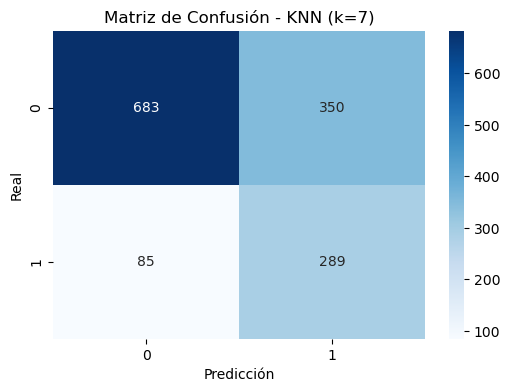

In [44]:
# Crear el clasificador KNN con K=7
knn = KNeighborsClassifier(n_neighbors=7)           # Creamos una instancia del clasificador KNN (K-Nearest Neighbors) con el número de vecinos (k) establecido en 7, lo que significa que el modelo considerará los 7 vecinos más cercanos para realizar las predicciones de clasificación.

# Entrenar el clasificador
knn.fit(X_train_bal, y_train_bal)                   # Entrenamos el modelo KNN utilizando el método fit() con el conjunto de entrenamiento balanceado (X_train_bal, y_train_bal), lo que ajusta el modelo a los datos de entrenamiento para que pueda realizar predicciones posteriormente.

# Predecir
y_pred_knn = knn.predict(X_test)                    # Utilizamos el método predict() del modelo KNN entrenado para realizar predicciones sobre el conjunto de prueba (X_test) y almacenamos las predicciones en la variable y_pred_knn.

# Mostrar el informe de métricas de clasificación
report = classification_report(y_test, y_pred_knn)  # Generamos un informe de clasificación utilizando la función classification_report() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo KNN (y_pred_knn) y proporciona métricas como precisión, recall, f1-score y soporte para cada clase.
print(report)

# Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)       # Calculamos la matriz de confusión utilizando la función confusion_matrix() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo KNN (y_pred_knn) y devuelve una matriz que muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
print("Matriz de confusión:")                       # Imprimimos un mensaje para indicar que a continuación se mostrará la matriz de confusión del modelo KNN.
print(cm_knn)                                       # Mostramos la matriz de confusión calculada para el modelo KNN, lo que nos permite evaluar el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

#Construimos un gráfico para los datos
plt.figure(figsize=(6, 4))                              # Creamos una figura con un tamaño de 6x4 pulgadas para el gráfico de la matriz de confusión.
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")  # Creamos un mapa de calor (heatmap) para visualizar la matriz de confusión del modelo KNN, con anotaciones que muestran los valores enteros (fmt="d") y utilizando una paleta de colores "Blues" para resaltar las diferencias en los valores de la matriz de confusión.
plt.title("Matriz de Confusión - KNN (k=7)")            # Añade un título al gráfico de la matriz de confusión para indicar que corresponde al modelo KNN con k=7.
plt.xlabel("Predicción")                                # Establece la etiqueta del eje x como "Predicción" para indicar que las columnas de la matriz de confusión representan las predicciones del modelo.
plt.ylabel("Real")                                      # Establece la etiqueta del eje y como "Real" para indicar que las filas de la matriz de confusión representan las etiquetas reales.
plt.show()                                              # mostramos el gráfico de la matriz de confusión.

Buscamos el mejor K

In [45]:
# Evaluar diferentes valores de K para KNN
resultados_knn = [] # Creamos una lista vacía llamada resultados_knn para almacenar los resultados de las métricas de evaluación para diferentes valores de K en el modelo KNN.

for k in range(1, 21):                          # Iteramos sobre los valores de K desde 1 hasta 20 para evaluar el rendimiento del modelo KNN con diferentes números de vecinos.
    knn = KNeighborsClassifier(n_neighbors=k)   # Creamos una instancia del clasificador KNN (K-Nearest Neighbors) con el número de vecinos (k) establecido en el valor actual de la iteración, lo que significa que el modelo considerará ese número específico de vecinos para realizar las predicciones de clasificación.
    knn.fit(X_train_bal, y_train_bal)           # Entrenamos el modelo KNN utilizando el método fit() con el conjunto de entrenamiento balanceado (X_train_bal, y_train_bal), lo que ajusta el modelo a los datos de entrenamiento para que pueda realizar predicciones posteriormente.
    y_pred = knn.predict(X_test)                # Utilizamos el método predict() del modelo KNN entrenado para realizar predicciones sobre el conjunto de prueba (X_test) y almacenamos las predicciones en la variable y_pred.

    resultados_knn.append({                                 # Agregamos un diccionario a la lista resultados_knn con las métricas de evaluación para el valor actual de K, incluyendo la precisión, recall y f1-score para la clase de churn (1) utilizando las funciones accuracy_score, precision_score, recall_score y f1_score de scikit-learn.
        "k": k,                                             # Especificamos el valor de K que se está evaluando en el modelo KNN.
        "accuracy": accuracy_score(y_test, y_pred),         # Calculamos la precisión general del modelo KNN utilizando la función accuracy_score() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas (y_pred) y devuelve la proporción de predicciones correctas.
        "precision_churn": precision_score(y_test, y_pred), # Calculamos la precisión para la clase de churn (1) utilizando la función precision_score() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas (y_pred) y devuelve la proporción de predicciones correctas para esa clase.
        "recall_churn": recall_score(y_test, y_pred),       # Calculamos el recall para la clase de churn (1) utilizando la función recall_score() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas (y_pred) y devuelve la proporción de muestras de esa clase que fueron correctamente clasificadas.
        "f1_churn": f1_score(y_test, y_pred),               # Calculamos el f1-score para la clase de churn (1) utilizando la función f1_score() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas (y_pred) y devuelve la media armónica de precisión y recall para esa clase.
    }) 
    
df_resultados_knn = pd.DataFrame(resultados_knn).round(2)                   # Convertimos la lista de resultados_knn en un DataFrame de pandas y redondeamos los valores a 2 decimales para una mejor presentación de las métricas de evaluación para cada valor de K en el modelo KNN.
display(df_resultados_knn.sort_values(by="recall_churn", ascending=False))  # Mostramos el DataFrame df_resultados_knn ordenado por la métrica de recall para la clase de churn (recall_churn) en orden descendente, lo que nos permite identificar fácilmente qué valor de K en el modelo KNN tiene el mejor rendimiento en términos de recall para la clase de churn.

,k,accuracy,precision_churn,recall_churn,f1_churn
14,15,0.69,0.45,0.83,0.58
18,19,0.69,0.45,0.82,0.58
16,17,0.69,0.45,0.82,0.58
12,13,0.69,0.45,0.82,0.59
10,11,0.69,0.46,0.81,0.58
19,20,0.70,0.46,0.80,0.59
13,14,0.71,0.47,0.80,0.59
15,16,0.70,0.46,0.80,0.59
17,18,0.70,0.47,0.80,0.59
8,9,0.70,0.46,0.80,0.59


In [46]:
# Identificar el mejor K basado en recall para la clase de churn
best_k = df_resultados_knn.loc[df_resultados_knn['recall_churn'].idxmax(), 'k'] # Utilizamos el método idxmax() para encontrar el índice del valor máximo de recall_churn en el DataFrame df_resultados_knn, y luego utilizamos ese índice para obtener el valor de K correspondiente a ese máximo recall_churn, lo que nos permite identificar el mejor valor de K para el modelo KNN en términos de recall para la clase de churn.
print("Mejor K:", best_k)                                                       # Imprimimos el mejor valor de K identificado para el modelo KNN en términos de recall para la clase de churn, lo que nos permite conocer qué configuración de K en el modelo KNN tiene el mejor rendimiento para predecir la clase de churn.

Mejor K: 15


Se evaluaron distintos valores de K en el modelo KNN utilizando validación sobre el conjunto de prueba. Se seleccionó K=15, ya que obtuvo el mayor recall para la clase churn (0.83), lo que permite identificar una mayor proporción de clientes en riesgo. Aunque el valor de F1 no es el más alto, se prioriza el recall debido a la importancia de minimizar falsos negativos en este tipo de problema.

              precision    recall  f1-score   support

           0       0.91      0.64      0.75      1033
           1       0.45      0.83      0.58       374

    accuracy                           0.69      1407
   macro avg       0.68      0.73      0.67      1407
weighted avg       0.79      0.69      0.71      1407

Matriz de confusión:
[[659 374]
 [ 65 309]]


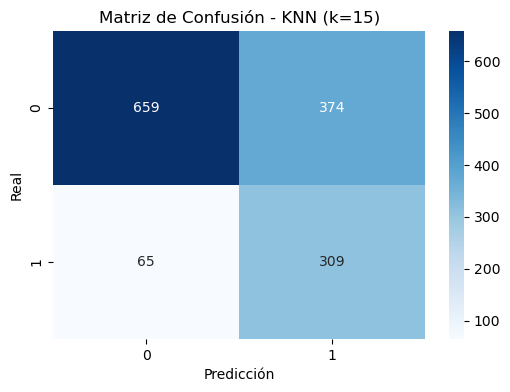

In [47]:
# Crear el clasificador KNN con K=15
knn = KNeighborsClassifier(n_neighbors=15)          # Creamos una instancia del clasificador KNN (K-Nearest Neighbors) con el número de vecinos (k) establecido en 15, lo que significa que el modelo considerará los 15 vecinos más cercanos para realizar las predicciones de clasificación, basándonos en el mejor valor de K identificado previamente para el modelo KNN en términos de recall para la clase de churn.

# Entrenar el clasificador
knn.fit(X_train_bal, y_train_bal)                   # Entrenamos el modelo KNN utilizando el método fit() con el conjunto de entrenamiento balanceado (X_train_bal, y_train_bal), lo que ajusta el modelo a los datos de entrenamiento para que pueda realizar predicciones posteriormente.

# Predecir
y_pred_knn = knn.predict(X_test)                    # Utilizamos el método predict() del modelo KNN entrenado para realizar predicciones sobre el conjunto de prueba (X_test) y almacenamos las predicciones en la variable y_pred_knn.

# Mostrar el informe de métricas de clasificación
report = classification_report(y_test, y_pred_knn)  # Generamos un informe de clasificación utilizando la función classification_report() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo KNN (y_pred_knn) y proporciona métricas como precisión, recall, f1-score y soporte para cada clase.
print(report)

# Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)       # Calculamos la matriz de confusión utilizando la función confusion_matrix() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo KNN (y_pred_knn) y devuelve una matriz que muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
print("Matriz de confusión:")                       # Imprimimos un mensaje para indicar que a continuación se mostrará la matriz de confusión del modelo KNN.
print(cm_knn)                                       # Mostramos la matriz de confusión calculada para el modelo KNN, lo que nos permite evaluar el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

#Construimos un gráfico para los datos
plt.figure(figsize=(6, 4))                              # Creamos una figura con un tamaño de 6x4 pulgadas para el gráfico de la matriz de confusión.
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")  # Creamos un mapa de calor (heatmap) para visualizar la matriz de confusión del modelo KNN, con anotaciones que muestran los valores enteros (fmt="d") y utilizando una paleta de colores "Blues" para resaltar las diferencias en los valores de la matriz de confusión.
plt.title("Matriz de Confusión - KNN (k=15)")           # Añade un título al gráfico de la matriz de confusión para indicar que corresponde al modelo KNN con k=15.
plt.xlabel("Predicción")                                # Establece la etiqueta del eje x como "Predicción" para indicar que las columnas de la matriz de confusión representan las predicciones del modelo.
plt.ylabel("Real")                                      # Establece la etiqueta del eje y como "Real" para indicar que las filas de la matriz de confusión representan las etiquetas reales.
plt.show()                                              # mostramos el gráfico de la matriz de confusión.   

El modelo KNN con K=15, entrenado sobre datos balanceados mediante SMOTE, presenta una mejora significativa en la detección de la clase minoritaria (churn), alcanzando un recall de 83%. Esto indica que el modelo es capaz de identificar la mayoría de los clientes que abandonan el servicio. Sin embargo, esta mejora implica un aumento en los falsos positivos, reduciendo la precisión. En este contexto, el modelo resulta adecuado cuando el objetivo principal es minimizar la pérdida de clientes, priorizando la detección temprana del churn.

### Cross Validation

Accuracy promedio: 0.69
Recall promedio: 0.71


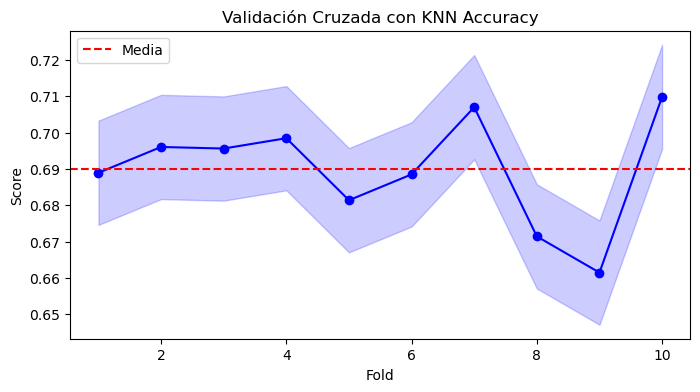

In [48]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)    # Creamos una instancia del objeto StratifiedKFold para realizar validación cruzada estratificada con 10 divisiones (n_splits=10), habilitando el barajado de los datos (shuffle=True) y estableciendo una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de validación cruzada, lo que nos permite evaluar el rendimiento del modelo KNN de manera más robusta y confiable al mantener la proporción de clases en cada división.

# Pipeline con SMOTE + KNN
pipeline = Pipeline([                               # Creamos un pipeline utilizando la clase Pipeline de imblearn para encadenar el proceso de sobremuestreo con SMOTE y el clasificador KNN en una sola secuencia de pasos.
    ('smote', SMOTE(random_state=42)),              # El primer paso del pipeline es el sobremuestreo utilizando SMOTE, con una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de balanceo de clases.
    ('knn', KNeighborsClassifier(n_neighbors=5))    # El segundo paso del pipeline es el clasificador KNN con el número de vecinos (k) establecido en 5, lo que significa que el modelo considerará los 5 vecinos más cercanos para realizar las predicciones de clasificación.
])

# Accuracy promedio
scores_acc = cross_val_score(pipeline, X_scaled, y, cv=cv)  # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de precisión (accuracy) promedio a través de las 10 divisiones de la validación cruzada.
print("Accuracy promedio:", round(scores_acc.mean(), 2))    # Imprimimos la precisión promedio obtenida a través de la validación cruzada, redondeada a 2 decimales, lo que nos permite evaluar el rendimiento general del modelo KNN con SMOTE en términos de precisión (accuracy) en el conjunto de datos.

# Recall promedio
scores_rec = cross_val_score(pipeline, X_scaled, y, cv=cv, scoring='recall')    # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de recall promedio a través de las 10 divisiones de la validación cruzada, especificando el parámetro scoring='recall' para calcular el recall en lugar de la precisión.
print("Recall promedio:", round(scores_rec.mean(), 2))                          # Imprimimos el recall promedio obtenido a través de la validación cruzada, redondeado a 2 decimales, lo que nos permite evaluar el rendimiento general del modelo KNN con SMOTE en términos de recall en el conjunto de datos.

# Calcular la media y la desviación estándar de los scores
mean_score = np.mean(scores_acc)    # Calculamos la media de los scores de precisión (accuracy) obtenidos a través de la validación cruzada utilizando la función mean() de NumPy, lo que nos permite obtener una medida central del rendimiento del modelo KNN con SMOTE en términos de precisión.
std_score = np.std(scores_acc)      # Calculamos la desviación estándar de los scores de precisión (accuracy) obtenidos a través de la validación cruzada utilizando la función std() de NumPy, lo que nos permite obtener una medida de la variabilidad o dispersión de los scores de precisión del modelo KNN con SMOTE en el conjunto de datos.

# Plotear los resultados de la validación cruzada
plt.figure(figsize=(8, 4))                                                                              # Creamos una figura con un tamaño de 8x4 pulgadas para el gráfico de los resultados de la validación cruzada.
plt.plot(range(1, 11), scores_acc, marker='o', linestyle='-', color='b')                                # Graficamos los scores de precisión (accuracy) obtenidos a través de la validación cruzada para cada una de las 10 divisiones utilizando la función plot() de Matplotlib, con marcadores en forma de círculo (marker='o'), líneas sólidas (linestyle='-') y color azul (color='b').
plt.fill_between(range(1, 11), scores_acc - std_score, scores_acc + std_score, alpha=0.2, color='b')    # Agregamos una banda de error al gráfico utilizando la función fill_between() de Matplotlib para mostrar la variabilidad de los scores de precisión (accuracy) a través de las 10 divisiones de la validación cruzada, con un nivel de transparencia (alpha=0.2) y color azul (color='b').
plt.axhline(y=mean_score, color='r', linestyle='--', label='Media')                                     # Agregamos una línea horizontal al gráfico utilizando la función axhline() de Matplotlib para indicar la media de los scores de precisión (accuracy) obtenidos a través de la validación cruzada, con color rojo (color='r'), líneas discontinuas (linestyle='--') y una etiqueta en la leyenda (label='Media').
plt.xlabel('Fold')                                                                                      # Establecemos la etiqueta del eje x como "Fold" para indicar que las divisiones de la validación cruzada se representan en el eje x.
plt.ylabel('Score')                                                                                     # Establecemos la etiqueta del eje y como "Score" para indicar que los scores de precisión (accuracy) obtenidos a través de la validación cruzada se representan en el eje y.
plt.title('Validación Cruzada con KNN Accuracy')                                                        # Añade un título al gráfico para indicar que corresponde a la validación cruzada realizada con el modelo KNN.
plt.legend()                                                                                            # Mostramos la leyenda del gráfico para identificar la línea que representa la media de los scores de precisión (accuracy) obtenidos a través de la validación cruzada.
plt.show()                                                                                              # mostramos el gráfico de los resultados de la validación cruzada.

Se aplicó validación cruzada estratificada utilizando un pipeline con SMOTE y KNN, obteniendo una accuracy promedio de 0.69 y un recall de 0.71. Estos resultados muestran una mejora significativa en la detección de la clase minoritaria (churn), manteniendo un desempeño estable entre los folds. Esto confirma que el uso de técnicas de balanceo mejora la capacidad del modelo para identificar clientes en riesgo.

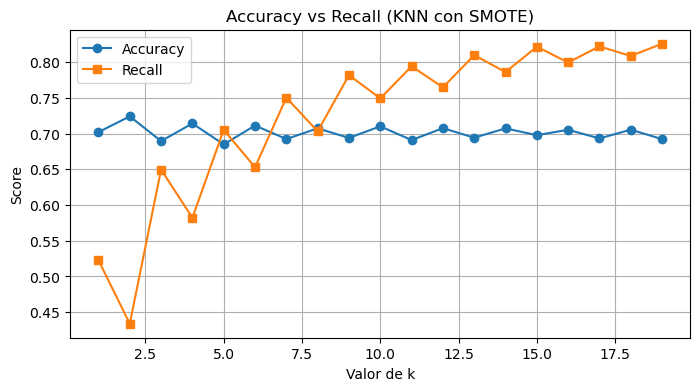

In [49]:
# Evaluar diferentes valores de K para KNN con validación cruzada
mean_acc = []   # Creamos una lista vacía llamada mean_acc para almacenar los valores promedio de precisión (accuracy) obtenidos a través de la validación cruzada para diferentes valores de K en el modelo KNN.
mean_rec = []   # Creamos una lista vacía llamada mean_rec para almacenar los valores promedio de recall obtenidos a través de la validación cruzada para diferentes valores de K en el modelo KNN.

k_values = range(1, 20) # Definimos un rango de valores de K desde 1 hasta 19 para evaluar el rendimiento del modelo KNN con diferentes números de vecinos utilizando validación cruzada.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Creamos una instancia del objeto StratifiedKFold para realizar validación cruzada estratificada con 5 divisiones (n_splits=5), habilitando el barajado de los datos (shuffle=True) y estableciendo una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de validación cruzada, lo que nos permite evaluar el rendimiento del modelo KNN de manera más robusta y confiable al mantener la proporción de clases en cada división.

for k in k_values:                                      # Iteramos sobre cada valor de K en el rango definido para evaluar el rendimiento del modelo KNN con diferentes números de vecinos utilizando validación cruzada.
    pipeline = Pipeline([                               # Creamos un pipeline utilizando la clase Pipeline de imblearn para encadenar el proceso de sobremuestreo con SMOTE y el clasificador KNN en una sola secuencia de pasos, donde el número de vecinos (k) se establece en el valor actual de la iteración.
        ('smote', SMOTE(random_state=42)),              # El primer paso del pipeline es el sobremuestreo utilizando SMOTE, con una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de balanceo de clases.            
        ('knn', KNeighborsClassifier(n_neighbors=k))    # El segundo paso del pipeline es el clasificador KNN con el número de vecinos (k) establecido en el valor actual de la iteración, lo que significa que el modelo considerará ese número específico de vecinos para realizar las predicciones de clasificación.
    ])
    
    acc = cross_val_score(pipeline, X_scaled, y, cv=cv, scoring='accuracy') # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de precisión (accuracy) promedio a través de las 5 divisiones de la validación cruzada, especificando el parámetro scoring='accuracy' para calcular la precisión.
    rec = cross_val_score(pipeline, X_scaled, y, cv=cv, scoring='recall')   # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de recall promedio a través de las 5 divisiones de la validación cruzada, especificando el parámetro scoring='recall' para calcular el recall.
    
    mean_acc.append(acc.mean()) # Agregamos el valor promedio de precisión (accuracy) obtenido a través de la validación cruzada para el valor actual de K a la lista mean_acc utilizando el método append(), lo que nos permite almacenar los resultados de precisión para cada valor de K evaluado.
    mean_rec.append(rec.mean()) # Agregamos el valor promedio de recall obtenido a través de la validación cruzada para el valor actual de K a la lista mean_rec utilizando el método append(), lo que nos permite almacenar los resultados de recall para cada valor de K evaluado.

# Gráfico combinado
plt.figure(figsize=(8,4))                                   # Creamos una figura con un tamaño de 8x4 pulgadas para el gráfico combinado de precisión (accuracy) y recall en función del valor de K en el modelo KNN.
plt.plot(k_values, mean_acc, marker='o', label='Accuracy')  # Graficamos los valores promedio de precisión (accuracy) obtenidos a través de la validación cruzada para cada valor de K utilizando la función plot() de Matplotlib, con marcadores en forma de círculo (marker='o') y una etiqueta en la leyenda (label='Accuracy') para identificar la línea que representa la precisión en el gráfico.
plt.plot(k_values, mean_rec, marker='s', label='Recall')    # Graficamos los valores promedio de recall obtenidos a través de la validación cruzada para cada valor de K utilizando la función plot() de Matplotlib, con marcadores en forma de cuadrado (marker='s') y una etiqueta en la leyenda (label='Recall') para identificar la línea que representa el recall en el gráfico.
plt.xlabel('Valor de k')                                    # Establecemos la etiqueta del eje x como "Valor de k" para indicar que los valores de K en el modelo KNN se representan en el eje x.
plt.ylabel('Score')                                         # Establecemos la etiqueta del eje y como "Score" para indicar que los valores de precisión (accuracy) y recall obtenidos a través de la validación cruzada se representan en el eje y.
plt.title('Accuracy vs Recall (KNN con SMOTE)')             # Añade un título al gráfico para indicar que corresponde a la comparación entre precisión (accuracy) y recall para el modelo KNN con SMOTE en función del valor de K.
plt.legend()                                                # Mostramos la leyenda del gráfico para identificar las líneas que representan la precisión (accuracy) y el recall en el gráfico.
plt.grid(True)                                              # Agregamos una cuadrícula al gráfico para mejorar la legibilidad de los valores de precisión (accuracy) y recall en función del valor de K.
plt.show()                                                  # mostramos el gráfico combinado de precisión (accuracy) y recall para el modelo KNN con SMOTE en función del valor de K.

Se compararon las métricas de accuracy y recall para distintos valores de K en el modelo KNN utilizando datos balanceados mediante SMOTE. Se observa que la accuracy se mantiene relativamente estable para distintos valores de K, mientras que el recall aumenta considerablemente a medida que K crece. Dado que el objetivo del problema es detectar clientes con churn, se priorizó el recall, seleccionando K=15 como el valor óptimo, ya que ofrece un buen equilibrio entre desempeño general y capacidad de detección de la clase minoritaria.

Accuracy promedio: 0.69
Recall promedio: 0.81


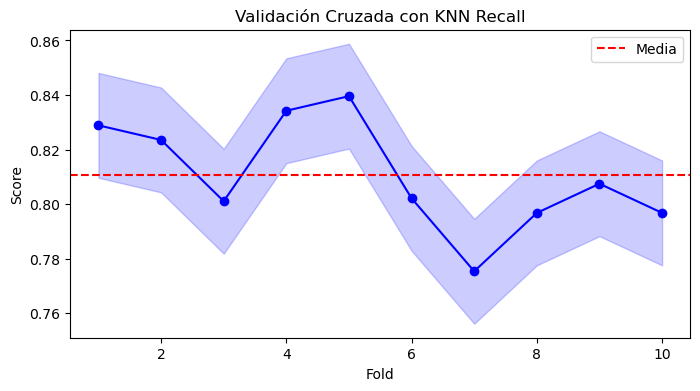

In [50]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)                # Creamos una instancia del objeto StratifiedKFold para realizar validación cruzada estratificada con 10 divisiones (n_splits=10), habilitando el barajado de los datos (shuffle=True) y estableciendo una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de validación cruzada, lo que nos permite evaluar el rendimiento del modelo KNN de manera más robusta y confiable al mantener la proporción de clases en cada división.

# Pipeline con SMOTE + KNN
pipeline = Pipeline([                               # Creamos un pipeline utilizando la clase Pipeline de imblearn para encadenar el proceso de sobremuestreo con SMOTE y el clasificador KNN en una sola secuencia de pasos.
    ('smote', SMOTE(random_state=42)),              # El primer paso del pipeline es el sobremuestreo utilizando SMOTE, con una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de balanceo de clases.
    ('knn', KNeighborsClassifier(n_neighbors=15))   # El segundo paso del pipeline es el clasificador KNN con el número de vecinos (k) establecido en 15, lo que significa que el modelo considerará los 15 vecinos más cercanos para realizar las predicciones de clasificación, basándonos en el mejor valor de K identificado previamente para el modelo KNN en términos de recall para la clase de churn.
])

# Accuracy promedio
scores_acc = cross_val_score(pipeline, X_scaled, y, cv=cv, scoring='accuracy')  # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de precisión (accuracy) promedio a través de las 10 divisiones de la validación cruzada, especificando el parámetro scoring='accuracy' para calcular la precisión.
print("Accuracy promedio:", round(scores_acc.mean(), 2))                        # Imprimimos la precisión promedio obtenida a través de la validación cruzada, redondeada a 2 decimales, lo que nos permite evaluar el rendimiento general del modelo KNN con SMOTE en términos de precisión (accuracy) en el conjunto de datos.

# Recall promedio
scores_rec = cross_val_score(pipeline, X_scaled, y, cv=cv, scoring='recall')    # Realizamos validación cruzada utilizando la función cross_val_score() de scikit-learn con el pipeline que incluye SMOTE y KNN, utilizando la versión estandarizada de las características numéricas (X_scaled) y la variable objetivo (y), con el objeto StratifiedKFold (cv) para evaluar el rendimiento del modelo en términos de recall promedio a través de las 10 divisiones de la validación cruzada, especificando el parámetro scoring='recall' para calcular el recall.       
print("Recall promedio:", round(scores_rec.mean(), 2))                          # Imprimimos el recall promedio obtenido a través de la validación cruzada, redondeado a 2 decimales, lo que nos permite evaluar el rendimiento general del modelo KNN con SMOTE en términos de recall en el conjunto de datos. 

# Calcular la media y la desviación estándar de los scores
mean_score = np.mean(scores_rec)        # Calculamos la media de los scores de recall obtenidos a través de la validación cruzada utilizando la función mean() de NumPy, lo que nos permite obtener una medida central del rendimiento del modelo KNN con SMOTE en términos de recall.
std_score = np.std(scores_rec)          # Calculamos la desviación estándar de los scores de recall obtenidos a través de la validación cruzada utilizando la función std() de NumPy, lo que nos permite obtener una medida de la variabilidad o dispersión de los scores de recall del modelo KNN con SMOTE en el conjunto de datos.

# Plotear los resultados de la validación cruzada
plt.figure(figsize=(8, 4))                                                                              # Creamos una figura con un tamaño de 8x4 pulgadas para el gráfico de los resultados de la validación cruzada.                                    
plt.plot(range(1, 11), scores_rec, marker='o', linestyle='-', color='b')                                # Graficamos los scores de recall obtenidos a través de la validación cruzada para cada una de las 10 divisiones utilizando la función plot() de Matplotlib, con marcadores en forma de círculo (marker='o'), líneas sólidas (linestyle='-') y color azul (color='b').
plt.fill_between(range(1, 11), scores_rec - std_score, scores_rec + std_score, alpha=0.2, color='b')    # Agregamos una banda de error al gráfico utilizando la función fill_between() de Matplotlib para mostrar la variabilidad de los scores de recall a través de las 10 divisiones de la validación cruzada, con un nivel de transparencia (alpha=0.2) y color azul (color='b').
plt.axhline(y=mean_score, color='r', linestyle='--', label='Media')                                     # Agregamos una línea horizontal al gráfico utilizando la función axhline() de Matplotlib para indicar la media de los scores de recall obtenidos a través de la validación cruzada, con color rojo (color='r'), líneas discontinuas (linestyle='--') y una etiqueta en la leyenda (label='Media').
plt.xlabel('Fold')                                                                                      # Establecemos la etiqueta del eje x como "Fold" para indicar que las divisiones de la validación cruzada se representan en el eje x.
plt.ylabel('Score')                                                                                     # Establecemos la etiqueta del eje y como "Score" para indicar que los scores de recall obtenidos a través de la validación cruzada se representan en el eje y.
plt.title('Validación Cruzada con KNN Recall')                                                          # Añade un título al gráfico para indicar que corresponde a la validación cruzada realizada con el modelo KNN.
plt.legend()                                                                                            # Mostramos la leyenda del gráfico para identificar la línea que representa la media de los scores de recall obtenidos a través de la validación cruzada.
plt.show()                                                                                              # mostramos el gráfico de los resultados de la validación cruzada.

Se aplicó validación cruzada estratificada utilizando un pipeline con SMOTE y KNN con K=15. El modelo obtuvo una accuracy promedio de 0.69 y un recall de 0.81, lo que indica una alta capacidad para detectar la clase minoritaria (churn). Además, los resultados muestran una baja variabilidad entre los folds, lo que evidencia estabilidad y robustez del modelo. Estos resultados confirman que la selección de K=15 es adecuada para el problema planteado.

### 2. Árboles De Desición

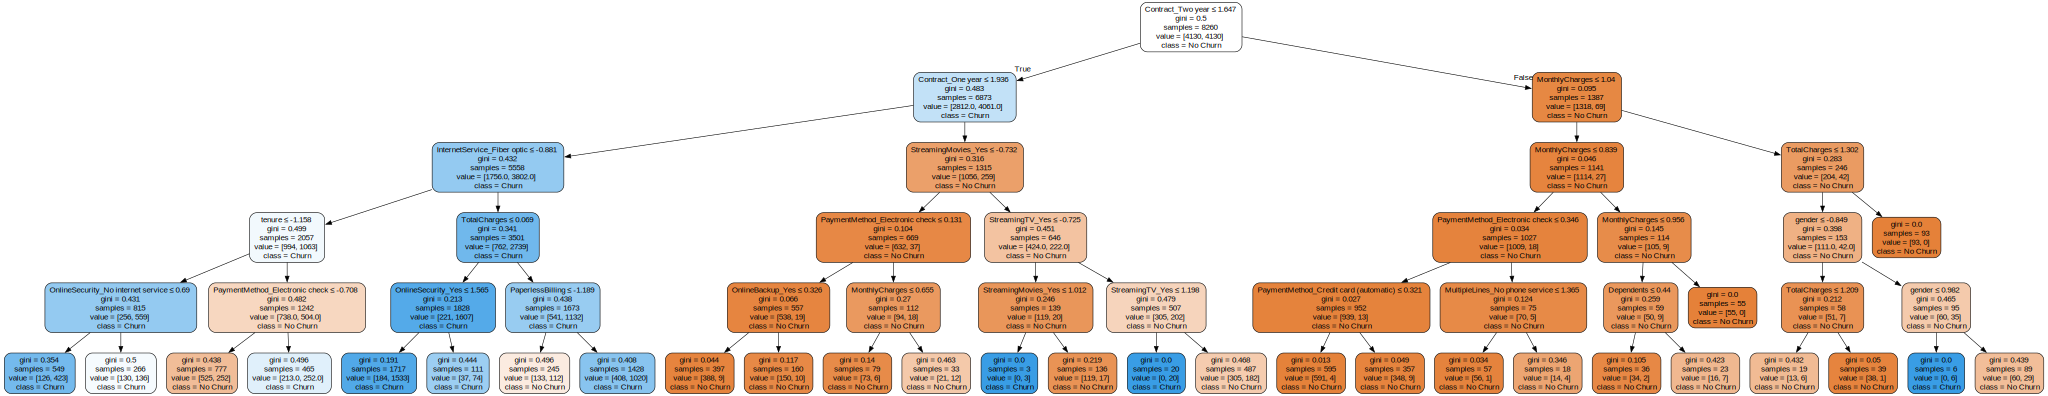

In [51]:
# Crear el clasificador Decision Tree 
tree = DecisionTreeClassifier(  # Creamos una instancia del clasificador Decision Tree (Árbol de Decisión) utilizando la clase DecisionTreeClassifier de scikit-learn, con los siguientes hiperparámetros:
    max_depth=5,                # Establecemos la profundidad máxima del árbol en 5, lo que limita la cantidad de niveles que el árbol puede tener, lo que ayuda a prevenir el sobreajuste (overfitting) al limitar la complejidad del modelo.
    min_samples_leaf=3,         # Establecemos el número mínimo de muestras requeridas para estar en una hoja del árbol en 3, lo que significa que cada hoja del árbol debe contener al menos 3 muestras para ser considerada como una hoja terminal, lo que también ayuda a prevenir el sobreajuste al evitar que el árbol se divida en ramas con muy pocas muestras.
    random_state=42             # Establecemos una semilla aleatoria de 42 para garantizar la reproducibilidad del modelo, lo que significa que cada vez que se ejecute el código con esta configuración, se obtendrán los mismos resultados debido a la misma inicialización aleatoria del modelo.
)

tree.fit(X_train_bal, y_train_bal)  # Entrenamos el modelo de árbol de decisión utilizando el método fit() con el conjunto de entrenamiento balanceado (X_train_bal, y_train_bal), lo que ajusta el modelo a los datos de entrenamiento para que pueda realizar predicciones posteriormente.

dot_data = export_graphviz(             # Exportamos el árbol de decisión entrenado a un formato DOT utilizando la función export_graphviz() de scikit-learn, lo que nos permite visualizar la estructura del árbol de decisión.
    tree,                               # El primer argumento es el modelo de árbol de decisión entrenado (tree) que queremos visualizar.
    out_file=None,                      # Especificamos que no queremos guardar el archivo DOT en disco estableciendo out_file=None, lo que nos permite obtener el contenido del archivo DOT como una cadena de texto en lugar de guardarlo como un archivo físico.
    feature_names=X.columns,            # Proporcionamos los nombres de las características (feature_names) utilizando las columnas del DataFrame X, lo que permite que los nodos del árbol de decisión muestren los nombres de las características en lugar de solo los índices numéricos.
    class_names=["No Churn", "Churn"],  # Proporcionamos los nombres de las clases (class_names) para que los nodos terminales del árbol de decisión muestren "No Churn" para la clase 0 y "Churn" para la clase 1, lo que facilita la interpretación de las predicciones del modelo.
    filled=True,                        # Especificamos que queremos que los nodos del árbol de decisión estén coloreados (filled=True) para mejorar la visualización y facilitar la identificación de las ramas y hojas del árbol.
    rounded=True,                       # Especificamos que queremos que los nodos del árbol de decisión tengan bordes redondeados (rounded=True) para mejorar la estética de la visualización del árbol.
    special_characters=True             # Especificamos que queremos permitir caracteres especiales en los nombres de las características y clases (special_characters=True) para asegurarnos de que los nombres se muestren correctamente en la visualización del árbol de decisión, incluso si contienen caracteres especiales o espacios.
)
# graficamos el árbol de decisión 
graph = graphviz.Source(dot_data)       # Creamos una fuente de gráfico utilizando la clase Source de graphviz, pasando el contenido del archivo DOT (dot_data) como argumento, lo que nos permite generar una visualización gráfica del árbol de decisión entrenado.
graph                                   # Mostramos la visualización del árbol de decisión utilizando el método view() de la fuente de gráfico, lo que abrirá una ventana con la representación gráfica del árbol de decisión entrenado, permitiéndonos analizar la estructura del modelo y las decisiones que toma para clasificar las muestras.


El árbol de decisión identifica que variables como el tipo de contrato, los cargos mensuales y el tipo de servicio de internet son los principales factores asociados al churn. En particular, los clientes con contratos mensuales y mayores cargos presentan mayor probabilidad de abandonar el servicio. El modelo logra capturar relaciones claras e interpretables entre las variables, lo que facilita la comprensión del comportamiento de los clientes.

In [52]:
# Guardar el gráfico del árbol de decisión como imagen PNG
graph.format = 'png'        # Establecemos el formato de salida del gráfico como PNG utilizando el atributo format de la fuente de gráfico, lo que nos permite guardar la visualización del árbol de decisión como una imagen en formato PNG.
graph.render('arbol_churn') # Renderizamos el gráfico y lo guardamos como una imagen PNG con el nombre 'arbol_churn.png'.

'arbol_churn.png'

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.75      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.74      1407

Matriz de confusión:
 [[735 298]
 [ 92 282]]


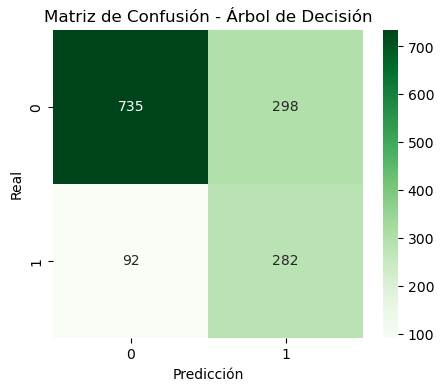

In [53]:
# Evaluar el modelo de árbol de decisión
y_pred_tree = tree.predict(X_test)                          # Utilizamos el método predict() del modelo de árbol de decisión entrenado para realizar predicciones sobre el conjunto de prueba (X_test) y almacenamos las predicciones en la variable y_pred_tree.

print(classification_report(y_test, y_pred_tree, digits=2)) # Generamos un informe de clasificación utilizando la función classification_report() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo de árbol de decisión (y_pred_tree) y proporciona métricas como precisión, recall, f1-score y soporte para cada clase, con los valores redondeados a 2 decimales (digits=2) para una mejor presentación de las métricas de evaluación del modelo.

cm = confusion_matrix(y_test, y_pred_tree)                  # Calculamos la matriz de confusión utilizando la función confusion_matrix() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el modelo de árbol de decisión (y_pred_tree) y devuelve una matriz que muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos para evaluar el rendimiento del modelo en términos de clasificación.
print("Matriz de confusión:\n", cm)                         # Imprimimos un mensaje para indicar que a continuación se mostrará la matriz de confusión del modelo de árbol de decisión, seguido de la matriz de confusión calculada, lo que nos permite evaluar el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

plt.figure(figsize=(5,4))                                   # Creamos una figura con un tamaño de 5x4 pulgadas para el gráfico de la matriz de confusión del modelo de árbol de decisión.
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")         # Creamos un mapa de calor (heatmap) para visualizar la matriz de confusión del modelo de árbol de decisión, con anotaciones que muestran los valores enteros (fmt="d") y utilizando una paleta de colores "Greens" para resaltar las diferencias en los valores de la matriz de confusión.
plt.title("Matriz de Confusión - Árbol de Decisión")        # Añade un título al gráfico de la matriz de confusión para indicar que corresponde al modelo de árbol de decisión.
plt.xlabel("Predicción")                                    # Establece la etiqueta del eje x como "Predicción" para indicar que las columnas de la matriz de confusión representan las predicciones del modelo.
plt.ylabel("Real")                                          # Establece la etiqueta del eje y como "Real" para indicar que las filas de la matriz de confusión representan las etiquetas reales.
plt.show()                                                  # mostramos el gráfico de la matriz de confusión del modelo de árbol de decisión.

El árbol de decisión presenta una accuracy superior (0.72) en comparación con KNN, lo que indica un mejor desempeño global. Sin embargo, su recall para la clase churn es menor (0.75), lo que implica que detecta menos clientes en riesgo. En contraste, el modelo KNN logra un recall más alto, siendo más efectivo para identificar churn. Por lo tanto, la elección del modelo depende del objetivo del problema: si se prioriza la detección de clientes en riesgo, KNN resulta más adecuado, mientras que el árbol ofrece un mejor equilibrio general y mayor interpretabilidad.

### Hiperparametros

Mejores hiperparámetros: {'tree__max_depth': 3, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Mejor recall en validación cruzada: 0.89
              precision    recall  f1-score   support

           0       0.92      0.55      0.69      1033
           1       0.41      0.87      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.62      1407
weighted avg       0.79      0.64      0.66      1407

Matriz de confusión:
 [[569 464]
 [ 48 326]]


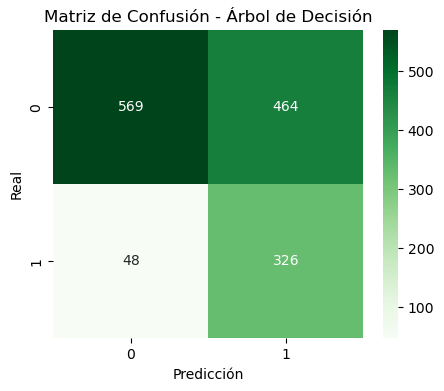

In [54]:
# Pipeline con SMOTE + Árbol
pipeline_tree = Pipeline([                              # Creamos un pipeline utilizando la clase Pipeline de imblearn para encadenar el proceso de sobremuestreo con SMOTE y el clasificador de árbol de decisión en una sola secuencia de pasos.
    ('smote', SMOTE(random_state=42)),                  # El primer paso del pipeline es el sobremuestreo utilizando SMOTE, con una semilla aleatoria de 42 para garantizar la reproducibilidad del proceso de balanceo de clases.
    ('tree', DecisionTreeClassifier(random_state=42))   # El segundo paso del pipeline es el clasificador de árbol de decisión, con una semilla aleatoria de 42 para garantizar la reproducibilidad del modelo, lo que significa que cada vez que se ejecute el código con esta configuración, se obtendrán los mismos resultados debido a la misma inicialización aleatoria del modelo.
])

# Hiperparámetros del árbol
param_grid = {                              # Definimos un diccionario llamado param_grid que contiene los hiperparámetros del árbol de decisión que queremos evaluar durante el proceso de ajuste de hiperparámetros utilizando GridSearchCV.
    'tree__max_depth': [3, 5, 7, 10],       # Especificamos diferentes valores para la profundidad máxima del árbol (max_depth) que queremos evaluar, incluyendo 3, 5, 7 y 10, lo que nos permite encontrar la configuración óptima de profundidad para el modelo de árbol de decisión.
    'tree__min_samples_split': [2, 5, 10],  # Especificamos diferentes valores para el número mínimo de muestras requeridas para dividir un nodo interno del árbol (min_samples_split) que queremos evaluar, incluyendo 2, 5 y 10, lo que nos permite encontrar la configuración óptima para la división de nodos en el modelo de árbol de decisión.
    'tree__min_samples_leaf': [1, 3, 5]     # Especificamos diferentes valores para el número mínimo de muestras requeridas para estar en una hoja del árbol (min_samples_leaf) que queremos evaluar, incluyendo 1, 3 y 5, lo que nos permite encontrar la configuración óptima para la cantidad de muestras en las hojas del modelo de árbol de decisión.
}

# GridSearchCV
grid = GridSearchCV(    # Creamos una instancia de GridSearchCV utilizando la clase GridSearchCV de scikit-learn para realizar una búsqueda exhaustiva de los mejores hiperparámetros del modelo de árbol de decisión dentro del pipeline que incluye SMOTE, utilizando el diccionario param_grid para especificar los hiperparámetros a evaluar, con una validación cruzada de 5 divisiones (cv=5), utilizando el recall como métrica de evaluación (scoring='recall') y aprovechando todos los núcleos disponibles para acelerar el proceso de búsqueda (n_jobs=-1).
    pipeline_tree,      # El primer argumento es el pipeline que incluye SMOTE y el clasificador de árbol de decisión (pipeline_tree) que queremos ajustar utilizando GridSearchCV.
    param_grid,         # El segundo argumento es el diccionario de hiperparámetros (param_grid) que contiene las diferentes configuraciones de hiperparámetros del árbol de decisión que queremos evaluar durante el proceso de ajuste.
    cv=5,               # Especificamos que queremos realizar una validación cruzada con 5 divisiones (cv=5) para evaluar el rendimiento del modelo de árbol de decisión con diferentes configuraciones de hiperparámetros.
    scoring='recall',   # Especificamos que queremos utilizar el recall como métrica de evaluación para seleccionar los mejores hiperparámetros, lo que significa que GridSearchCV seleccionará la configuración de hiperparámetros que maximice el recall del modelo de árbol de decisión durante la validación cruzada.
    n_jobs=-1           # Especificamos que queremos utilizar todos los núcleos disponibles en la máquina para acelerar el proceso de búsqueda de hiperparámetros, lo que permite que GridSearchCV ejecute las evaluaciones de diferentes configuraciones de hiperparámetros en paralelo, reduciendo el tiempo total necesario para encontrar la mejor configuración.
)

# Entrenar solo con train original
grid.fit(X_train, y_train)                                                  # Entrenamos el modelo utilizando el método fit() de GridSearchCV con el conjunto de entrenamiento original (X_train, y_train), lo que ajusta el modelo de árbol de decisión con diferentes configuraciones de hiperparámetros especificados en param_grid utilizando validación cruzada para evaluar el rendimiento del modelo y seleccionar la mejor configuración de hiperparámetros basada en el recall.

print("Mejores hiperparámetros:", grid.best_params_)                        # Imprimimos un mensaje para indicar que a continuación se mostrarán los mejores hiperparámetros encontrados por GridSearchCV, seguido de los mejores hiperparámetros almacenados en el atributo best_params_ de GridSearchCV, lo que nos permite conocer la configuración óptima de hiperparámetros para el modelo de árbol de decisión basado en el recall durante la validación cruzada.
print("Mejor recall en validación cruzada:", round(grid.best_score_, 2))    # Imprimimos un mensaje para indicar que a continuación se mostrará el mejor recall obtenido en la validación cruzada por GridSearchCV, seguido del mejor recall almacenado en el atributo best_score_ de GridSearchCV, redondeado a 2 decimales, lo que nos permite conocer el rendimiento óptimo del modelo de árbol de decisión basado en el recall durante la validación cruzada.

# Mejor modelo
best_tree = grid.best_estimator_                                            # Almacenamos el mejor modelo de árbol de decisión encontrado por GridSearchCV en la variable best_tree utilizando el atributo best_estimator_ de GridSearchCV, lo que nos permite utilizar este modelo con la configuración óptima de hiperparámetros para realizar predicciones y evaluaciones posteriores.

# Predicción en test original
y_pred_tree = best_tree.predict(X_test)                                     # Utilizamos el método predict() del mejor modelo de árbol de decisión (best_tree) para realizar predicciones sobre el conjunto de prueba original (X_test) y almacenamos las predicciones en la variable y_pred_tree, lo que nos permite evaluar el rendimiento del modelo de árbol de decisión con la mejor configuración de hiperparámetros en el conjunto de prueba.

# Métricas
print(classification_report(y_test, y_pred_tree, digits=2))                 # Generamos un informe de clasificación utilizando la función classification_report() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el mejor modelo de árbol de decisión (y_pred_tree) y proporciona métricas como precisión, recall, f1-score y soporte para cada clase, con los valores redondeados a 2 decimales (digits=2) para una mejor presentación de las métricas de evaluación del modelo.

cm = confusion_matrix(y_test, y_pred_tree)                                  # Calculamos la matriz de confusión utilizando la función confusion_matrix() de scikit-learn, que compara las etiquetas reales (y_test) con las etiquetas predichas por el mejor modelo de árbol de decisión (y_pred_tree) y devuelve una matriz que muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos para evaluar el rendimiento del modelo en términos de clasificación.
print("Matriz de confusión:\n", cm)                                         # Imprimimos un mensaje para indicar que a continuación se mostrará la matriz de confusión del mejor modelo de árbol de decisión, seguido de la matriz de confusión calculada, lo que nos permite evaluar el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

# Heatmap
plt.figure(figsize=(5,4))                                                   # Creamos una figura con un tamaño de 5x4 pulgadas para el gráfico de la matriz de confusión del mejor modelo de árbol de decisión.
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")                         # Creamos un mapa de calor (heatmap) para visualizar la matriz de confusión del mejor modelo de árbol de decisión, con anotaciones que muestran los valores enteros (fmt="d") y utilizando una paleta de colores "Greens" para resaltar las diferencias en los valores de la matriz de confusión.
plt.title("Matriz de Confusión - Árbol de Decisión")                        # Añade un título al gráfico de la matriz de confusión para indicar que corresponde al mejor modelo de árbol de decisión.
plt.xlabel("Predicción")                                                    # Establece la etiqueta del eje x como "Predicción" para indicar que las columnas de la matriz de confusión representan las predicciones del modelo.
plt.ylabel("Real")                                                          # Establece la etiqueta del eje y como "Real" para indicar que las filas de la matriz de confusión representan las etiquetas reales.
plt.show()                                                                  # mostramos el gráfico de la matriz de confusión del mejor modelo de árbol de decisión.

El árbol de decisión optimizado mediante GridSearchCV y SMOTE logró un recall de 87% sobre la clase churn, convirtiéndose en el modelo con mayor capacidad de detección de clientes en riesgo. Sin embargo, esta mejora se obtiene a costa de una menor accuracy y un aumento importante en los falsos positivos. Por ello, este modelo resulta adecuado cuando el objetivo principal es minimizar la pérdida de clientes, priorizando la detección por sobre la precisión global.

### 5. Evaluar el rendimiento de los modelos utilizando métricas de evaluación pertinentes, como precisión, sensibilidad, valor F1, entre otras.

## Comparación de Modelos

| Modelo                         | Accuracy | Precision (Churn) | Recall (Churn) | F1 (Churn) | Observación |
|--------------------------------|----------|-------------------|----------------|-----------|-------------|
| KNN (K=15 + SMOTE)             | 0.69     | 0.45              | **0.83**       | 0.58      | Mejor detección de churn, modelo robusto |
| Árbol de Decisión (Base + SMOTE) | **0.72** | 0.49              | 0.75           | 0.59      | Mejor equilibrio general |
| Árbol de Decisión (Optimizado + SMOTE) | 0.64     | 0.41              | **0.87**       | 0.56      | Máxima detección de churn, pero muchos falsos positivos |

Se comparan los modelos utilizando métricas enfocadas en la clase positiva (churn), dado el interés en detectar clientes en riesgo.

El modelo más adecuado depende del objetivo del negocio. Si se busca maximizar la detección de clientes en riesgo, el árbol optimizado con SMOTE es la mejor opción debido a su alto recall. Sin embargo, si se requiere un equilibrio entre precisión y desempeño general, el árbol base o el modelo KNN representan alternativas más balanceadas.

Se selecciona el Árbol de Decisión optimizado con SMOTE como modelo final, ya que presenta el mayor recall (0.87), permitiendo detectar la mayor cantidad de clientes en riesgo. Aunque aumenta los falsos positivos, este trade-off es aceptable dado que el objetivo principal es minimizar la pérdida de clientes.